In [1]:
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt
import os

In [2]:
if not os.path.isdir(r"./model"):
    os.mkdir("./model")

In [3]:
df = pd.read_csv(r"./used_cars.csv")
df.head()
# df.dtypes

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [4]:
df_model = df[["model_year","milage","price"]]
df_model

,model_year,milage,price
0,2013,"51,000 mi.","$10,300"
1,2021,"34,742 mi.","$38,005"
2,2022,"22,372 mi.","$54,598"
3,2015,"88,900 mi.","$15,500"
4,2021,"9,835 mi.","$34,999"
...,...,...,...
4004,2023,714 mi.,"$349,950"
4005,2022,"10,900 mi.","$53,900"
4006,2022,"2,116 mi.","$90,998"
4007,2020,"33,000 mi.","$62,999"


In [5]:
# data cleanup
df_model["milage"] = df_model["milage"].str.replace(",","").str.replace("mi.","")
df_model["price"] = df_model["price"].str.replace("$","").str.replace(",","")
#print(df_model, df_model.dtypes)
df_model = df_model.astype(float)
print(df_model, df_model.dtypes)
#print(df_model.corr())


      model_year   milage     price
0         2013.0  51000.0   10300.0
1         2021.0  34742.0   38005.0
2         2022.0  22372.0   54598.0
3         2015.0  88900.0   15500.0
4         2021.0   9835.0   34999.0
...          ...      ...       ...
4004      2023.0    714.0  349950.0
4005      2022.0  10900.0   53900.0
4006      2022.0   2116.0   90998.0
4007      2020.0  33000.0   62999.0
4008      2020.0  43000.0   40000.0

[4009 rows x 3 columns] model_year    float64
milage        float64
price         float64
dtype: object


/var/folders/gp/4dnnkdm55819tsnwhpp3hrn00000gp/T/ipykernel_11087/196898954.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["milage"] = df_model["milage"].str.replace(",","").str.replace("mi.","")
/var/folders/gp/4dnnkdm55819tsnwhpp3hrn00000gp/T/ipykernel_11087/196898954.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["price"] = df_model["price"].str.replace("$","").str.replace(",","")


In [6]:
df_model.corr()

,model_year,milage,price
model_year,1.000000,-0.617720,0.199496
milage,-0.617720,1.000000,-0.305528
price,0.199496,-0.305528,1.000000


In [7]:
X = torch.column_stack(
    (torch.tensor(df_model["model_year"],dtype = torch.float32 ),
    torch.tensor(df_model["milage"],dtype = torch.float32))
)
print(X,X.ndim, X.shape)
# normalize - Zscore normalisation - x - xmean/xstd
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
print(X_mean,X_std)
X = (X-X_mean)/X_std
print(X,X.max(),X.min())

tensor([[ 2013., 51000.],
        [ 2021., 34742.],
        [ 2022., 22372.],
        ...,
        [ 2022.,  2116.],
        [ 2020., 33000.],
        [ 2020., 43000.]]) 2 torch.Size([4009, 2])
tensor([ 2015.5156, 64717.5547]) tensor([6.1048e+00, 5.2297e+04])
tensor([[-0.4121, -0.2623],
        [ 0.8984, -0.5732],
        [ 1.0622, -0.8097],
        ...,
        [ 1.0622, -1.1970],
        [ 0.7346, -0.6065],
        [ 0.7346, -0.4153]]) tensor(6.5068) tensor(-6.8005)


In [8]:
## Output tensor
y = torch.tensor(df_model["price"],dtype = torch.float32)
y_mean = y.mean()
y_std = y.std()
y = (y-y_mean)/y_std
y = y.reshape(-1,1)
print(y,y.max(),y.min(), y.shape)

tensor([[-0.4352],
        [-0.0832],
        [ 0.1276],
        ...,
        [ 0.5901],
        [ 0.2343],
        [-0.0578]]) tensor(36.9649) tensor(-0.5406) torch.Size([4009, 1])


In [9]:
## Build the model
model = nn.Linear(in_features=2,out_features=1)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

In [10]:
## Run the training cycle
losses = []
for i in range(10000):
    optimizer.zero_grad()
    output = model(X)
    loss = loss_fn(output, y)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if i%100 ==0:
        print(loss)  


tensor(1.0856, grad_fn=<MseLossBackward0>)
tensor(1.0324, grad_fn=<MseLossBackward0>)
tensor(0.9977, grad_fn=<MseLossBackward0>)
tensor(0.9745, grad_fn=<MseLossBackward0>)
tensor(0.9584, grad_fn=<MseLossBackward0>)
tensor(0.9470, grad_fn=<MseLossBackward0>)
tensor(0.9387, grad_fn=<MseLossBackward0>)
tensor(0.9325, grad_fn=<MseLossBackward0>)
tensor(0.9277, grad_fn=<MseLossBackward0>)
tensor(0.9240, grad_fn=<MseLossBackward0>)
tensor(0.9210, grad_fn=<MseLossBackward0>)
tensor(0.9186, grad_fn=<MseLossBackward0>)
tensor(0.9167, grad_fn=<MseLossBackward0>)
tensor(0.9151, grad_fn=<MseLossBackward0>)
tensor(0.9137, grad_fn=<MseLossBackward0>)
tensor(0.9126, grad_fn=<MseLossBackward0>)
tensor(0.9117, grad_fn=<MseLossBackward0>)
tensor(0.9109, grad_fn=<MseLossBackward0>)
tensor(0.9102, grad_fn=<MseLossBackward0>)
tensor(0.9096, grad_fn=<MseLossBackward0>)
tensor(0.9091, grad_fn=<MseLossBackward0>)
tensor(0.9087, grad_fn=<MseLossBackward0>)
tensor(0.9084, grad_fn=<MseLossBackward0>)
tensor(0.90

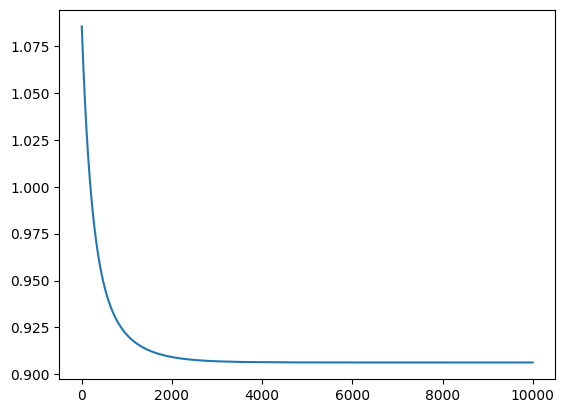

In [11]:
plt.plot(losses)

In [12]:
X_pred = torch.tensor([[2020,10000],[2021,10000],[2022,10000]],dtype = torch.float32)
pred = model((X_pred-X_mean)/X_std)
print(pred, pred*y_std+y_mean)

tensor([[0.3212],
        [0.3240],
        [0.3269]], grad_fn=<AddmmBackward0>) tensor([[69832.3672],
        [70058.5469],
        [70284.7344]], grad_fn=<AddBackward0>)


In [13]:
## Save and resume the built model
torch.save(X_mean, "./model/X_mean.pt")
torch.save(X_std, "./model/X_std.pt")
torch.save(y_mean, "./model/y_mean.pt")
torch.save(y_std, "./model/y_std.pt")
torch.save(model.state_dict(), "./model/model.pt" )